# Ocena 3.0
Obliczanie energii oddziaływań między nukleotydami (Potencjał Lennarda-Jonesa)

Niezbędne biblioteki oraz parametry

In [45]:
import math
import os
import glob
import statistics

EPSILON = 0.086  # kcal/mol
SIGMA = 3.4      # Angstrom


Wczytanie wszystkich plików .pdb z katalogu 

In [46]:
directory = "GC\\lj"
files = glob.glob(os.path.join(directory, "*.pdb"))
    
if not files:
    print(f"Nie znaleziono plików .pdb w katalogu '{directory}'.")

Funkcja, która wczytuje atomy węgla z pliku PDB. Zwraca słownik, gdzie kluczem jest identyfikator nukleotydu, a wartością lista atomów węgla.

In [47]:
def parse_pdb(filepath):
    residues = {}
    
    try:
        with open(filepath, 'r') as f:
            for line in f:
                if line.startswith("ATOM") or line.startswith("HETATM"):
                    # Standard PDB columns
                    atom_name = line[12:16].strip()
                    res_seq = line[22:26].strip()
                    chain_id = line[21]
                    
                    # Sprawdzamy czy to węgiel (zaczyna się od C i nie jest np. Ca - Wapniem)
                    element = line[76:78].strip()
                    if not element:
                        # Fallback: sprawdzamy pierwszą literę nazwy atomu
                        is_carbon = atom_name.startswith('C') and not atom_name.startswith('CL') and not atom_name.startswith('CA') # CA to węgiel alfa w białkach, ale też symbol wapnia, tu zakładamy nukleotydy
                    else:
                        is_carbon = element == 'C'

                    if atom_name.startswith('C'): # Uproszczenie dla nukleotydów
                        x = float(line[30:38])
                        y = float(line[38:46])
                        z = float(line[46:54])
                        
                        # Unikalny klucz dla rezyduum (łańcuch + numer)
                        res_id = f"{chain_id}_{res_seq}"
                        
                        if res_id not in residues:
                            residues[res_id] = []
                        
                        residues[res_id].append({'x': x, 'y': y, 'z': z, 'name': atom_name})
    except Exception as e:
        print(f"Błąd odczytu pliku {filepath}: {e}")
        return None
    return residues


Funkcja obliczająca odległość euklidesową między dwoma atomami.

In [48]:
def calculate_distance(atom1, atom2):
    dx = atom1['x'] - atom2['x']
    dy = atom1['y'] - atom2['y']
    dz = atom1['z'] - atom2['z']
    return math.sqrt(dx*dx + dy*dy + dz*dz)

Funkcja obliczająca potencjał LJ dla zadanej odległości r.

In [49]:
def lennard_jones_potential(r, epsilon, sigma):
    if r == 0:
        return float('inf') # Zabezpieczenie przed dzieleniem przez zero
    
    # Optymalizacja: obliczamy (sigma/r)^6 raz
    sr6 = (sigma / r) ** 6
    # Wzór: 4 * eps * ((sigma/r)^12 - (sigma/r)^6)
    return 4 * epsilon * (sr6**2 - sr6)

Główna pętla w której tworzone są listy A i B oraz obliczana jest całkowita energia układu, sumując potencjał Lennarda-Jonesa dla każdej możliwej pary, w której jeden atom pochodzi z Listy A, a drugi z Listy B.

In [50]:
results = []
for filepath in files:
    residues = parse_pdb(filepath)
        
    if not residues or len(residues) < 2:
        # Pomijamy pliki, które nie mają dwóch osobnych nukleotydów
        continue
            
    # Zakładamy, że w pliku są dokładnie dwa nukleotydy (lub bierzemy dwa pierwsze)
    keys = list(residues.keys())
    nucleotide_A = residues[keys[0]]
    nucleotide_B = residues[keys[1]]
        
    total_energy = 0.0
        
    # Podwójna pętla po atomach (A vs B)
    for atom_a in nucleotide_A:
        for atom_b in nucleotide_B:
            dist = calculate_distance(atom_a, atom_b)
            energy = lennard_jones_potential(dist, EPSILON, SIGMA)
            total_energy += energy
        
    results.append((filepath, total_energy))

# Sortowanie wyników rosnąco według energii
results.sort(key=lambda x: x[1])

if not results:
    print("Brak poprawnych danych do analizy.")

Wyświetlenie wyników

In [51]:
print("5 o najniższj energii (najstabilniejsze struktury):")
for res in results[:5]:
    print(f"{os.path.basename(res[0])}: {res[1]:.4f} kcal/mol")

print("\n5 o najwyższej energii (najmniej stabilne struktury):")
for res in results[-5:]:
    print(f"{os.path.basename(res[0])}: {res[1]:.4f} kcal/mol")

best_struct = results[0]
worst_struct = results[-1]

print("\nPodsumowanie:")
print(f"Najniższa energia:   {os.path.basename(best_struct[0])} (E = {best_struct[1]:.4f} kcal/mol)")
print(f"Najwyższa energia: {os.path.basename(worst_struct[0])} (E = {worst_struct[1]:.4f} kcal/mol)")

5 o najniższj energii (najstabilniejsze struktury):
GC_33.pdb: -1.6750 kcal/mol
GC_53.pdb: -0.3253 kcal/mol
GC_49.pdb: -0.2975 kcal/mol
GC_34.pdb: -0.1911 kcal/mol
GC_4.pdb: -0.1420 kcal/mol

5 o najwyższej energii (najmniej stabilne struktury):
GC_94.pdb: 23.5623 kcal/mol
GC_3.pdb: 75445.6105 kcal/mol
GC_69.pdb: 264464.7677 kcal/mol
GC_7.pdb: 7243695.2694 kcal/mol
GC_96.pdb: 11028519046.7737 kcal/mol

Podsumowanie:
Najniższa energia:   GC_33.pdb (E = -1.6750 kcal/mol)
Najwyższa energia: GC_96.pdb (E = 11028519046.7737 kcal/mol)


## Wizualizacja cząsteczek w pyMOL
Po otworzeniu obu struktur w pyMOL widać wyraźne różnice w rozmieszczeniu nukleotydów w przestrzeni. W przypadku pliku GC_33.pdb (o najniższej energii) cząsteczki są od siebie oddalone, 
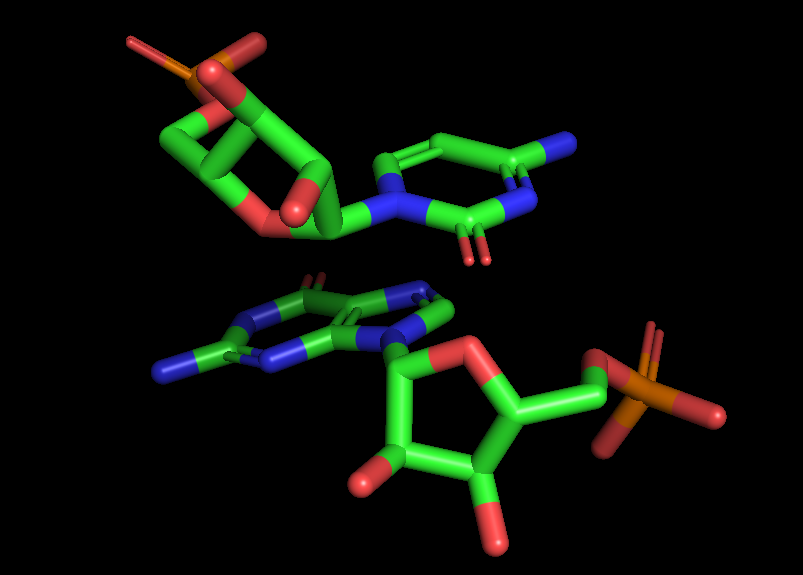

natomiast w przypadku pliku GC_96.pdb (onajwyższej energii) cząsteczki w dużym stopniu nachodzą na siebie. 
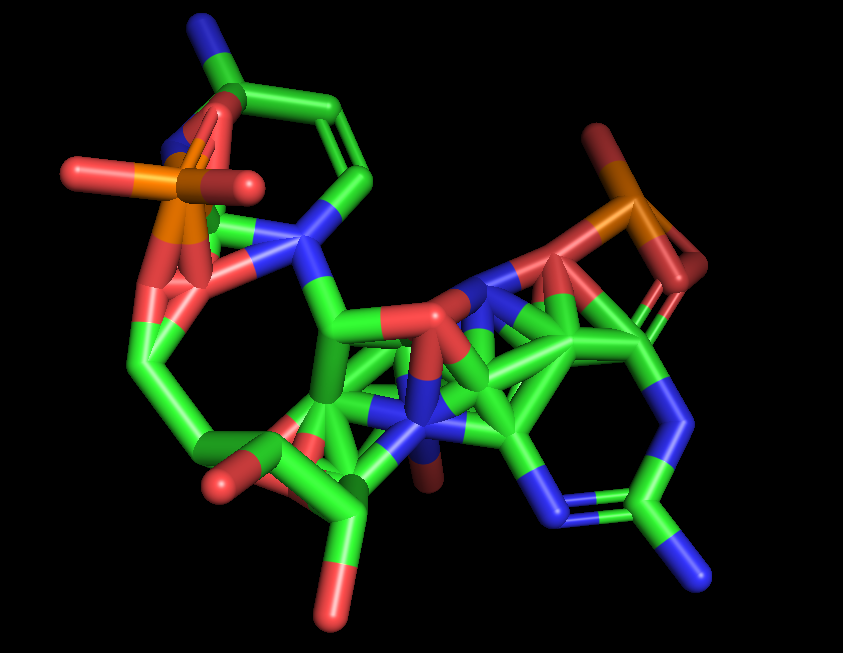

# Ocena 3.5
Statystyka Boltzmanna i prawdopodobieństwo względne

Obliczenie energią odniesienia U(y)
Energia odniesienia to mediana ze wszystkich 100 wartości energii.

In [52]:
U_y = statistics.median(results[i][1] for i in range(len(results)))
print(f"Mediana energii oddziaływań: U_y = {U_y:.4f} kcal/mol")

Mediana energii oddziaływań: U_y = -0.0005 kcal/mol


Parametry

In [53]:
# Parametry fizyczne
T = 300.0            # Temperatura w Kelvinach
kB = 1.987204259e-3  # Stała Boltzmanna w kcal/(mol*K)
RT = kB * T          # Energia termiczna (mianownik we wzorze)

print(f"Temperatura: {T} K")
print(f"RT (kBT): {RT:.4f} kcal/mol")

Temperatura: 300.0 K
RT (kBT): 0.5962 kcal/mol


Obliczenie wartości $$ \frac{P(x)}{P(y)} = \exp\left( -\frac{U(x) - U(y)}{k_B T} \right) $$ dla wszystkich 100 struktur

In [54]:
# Nagłówek 
print(f"{'PLIK':<20} {'ENERGIA':<20} {'P(x)/P(y)':<20}")

# Lista do przechowywania wyników
final_results = []

for filepath, energy in results:
    # Obliczenia
    delta_u = energy - U_y
    try:
        relative_prob = math.exp(-delta_u / RT)
    except OverflowError:
        relative_prob = float('inf')

    final_results.append((filepath, energy, relative_prob))

    # Wyświetlanie bez "dziwnych tabelek" - same spacje
    filename = os.path.basename(filepath)
    print(f"{filename:<20} {energy:<20.4f} {relative_prob:.4e}")

PLIK                 ENERGIA              P(x)/P(y)           
GC_33.pdb            -1.6750              1.6592e+01
GC_53.pdb            -0.3253              1.7244e+00
GC_49.pdb            -0.2975              1.6459e+00
GC_34.pdb            -0.1911              1.3769e+00
GC_4.pdb             -0.1420              1.2680e+00
GC_55.pdb            -0.1119              1.2055e+00
GC_76.pdb            -0.0507              1.0879e+00
GC_1.pdb             -0.0496              1.0859e+00
GC_74.pdb            -0.0411              1.0704e+00
GC_67.pdb            -0.0393              1.0672e+00
GC_17.pdb            -0.0318              1.0538e+00
GC_6.pdb             -0.0272              1.0458e+00
GC_73.pdb            -0.0264              1.0445e+00
GC_2.pdb             -0.0255              1.0429e+00
GC_43.pdb            -0.0211              1.0353e+00
GC_8.pdb             -0.0192              1.0319e+00
GC_89.pdb            -0.0161              1.0266e+00
GC_14.pdb            -0.0143        

Weryfikacja

In [55]:
print("Weryfikacja wyników:")
atoms_below_median = [p for f, e, p in final_results if e < U_y]
atoms_above_median = [p for f, e, p in final_results if e > U_y]

# Sprawdzenie czy dla energii mniejszej od mediany P > 1
check_better = all(p > 1 for p in atoms_below_median)
# Sprawdzenie czy dla energii większej od mediany P < 1
check_worse = all(p < 1 for p in atoms_above_median)

if check_better and check_worse:
    print("Pozytywna")
else:
    print("Negatywna")

Weryfikacja wyników:
Pozytywna


Pozytywna weryfikacja oznacza, że wszystkie struktury stabilniejsze od mediany mają P > 1, a mniej stabilne P < 1.

# Ocena 4.0
## Analiza geometrii wiązań wodorowych w parach G-C
Badanie stabilności i długości wiązań wodorowych (O6-N4, N1-N3, N2-O2) oraz dopasowanie rozkładu normalnego do uzyskanych danych.

Niezbędne biblioteki

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from Bio.PDB import PDBParser
import warnings

Znajdowanie odpowiednich atomów i gromadzenie odległości

In [57]:
# Lista na wyniki dla trzech typów wiązań
d_O6_N4 = [] # Wiązanie górne: O6(G) - N4(C)
d_N1_N3 = [] # Wiązanie środkowe: N1(G) - N3(C)
d_N2_O2 = [] # Wiązanie dolne: N2(G) - O2(C)

# Ścieżka do katalogu z parami GC (zwróć uwagę na małe 'gc' w nazwie podkatalogu)
gc_directory = os.path.join("GC", "gc")
gc_files = glob.glob(os.path.join(gc_directory, "*.pdb"))

parser = PDBParser(QUIET=True)

for filepath in gc_files:
    try:
        structure = parser.get_structure('GC_pair', filepath)
        
        # Szukamy Guaniny (G) i Cytozyny (C)
        # Zakładamy, że w pliku są tylko te dwa lub szukamy po nazwach
        g_res = None
        c_res = None
        
        for model in structure:
            for chain in model:
                for residue in chain:
                    res_name = residue.get_resname().strip().upper()
                    # Nazwy mogą być różne: 'G', 'GUA', 'DG', '5GP' itp.
                    if res_name in ['G', 'DG', 'GUA', '5GP']:
                        g_res = residue
                    elif res_name in ['C', 'DC', 'CYT', '5CM']:
                        c_res = residue
        
        if g_res and c_res:
            # Obliczamy odległości (Biopython pozwala odejmować atomy, by dostać dystans)
            # Używamy try-except, gdyby brakowało któregoś atomu (np. uszkodzona struktura)
            try:
                # 1. O6(G) - N4(C)
                dist1 = g_res['O6'] - c_res['N4']
                d_O6_N4.append(dist1)
                
                # 2. N1(G) - N3(C)
                dist2 = g_res['N1'] - c_res['N3']
                d_N1_N3.append(dist2)
                
                # 3. N2(G) - O2(C)
                dist3 = g_res['N2'] - c_res['O2']
                d_N2_O2.append(dist3)
                
            except KeyError as e:
                # Pomijamy plik, jeśli brakuje konkretnego atomu
                continue
                
    except Exception as e:
        print(f"Błąd w pliku {filepath}: {e}")

print(f"Zebrano dane z {len(d_O6_N4)} poprawnych struktur.")

Zebrano dane z 1000 poprawnych struktur.


Generowanie wykresu i dopasowanie do krzywej Gaussa

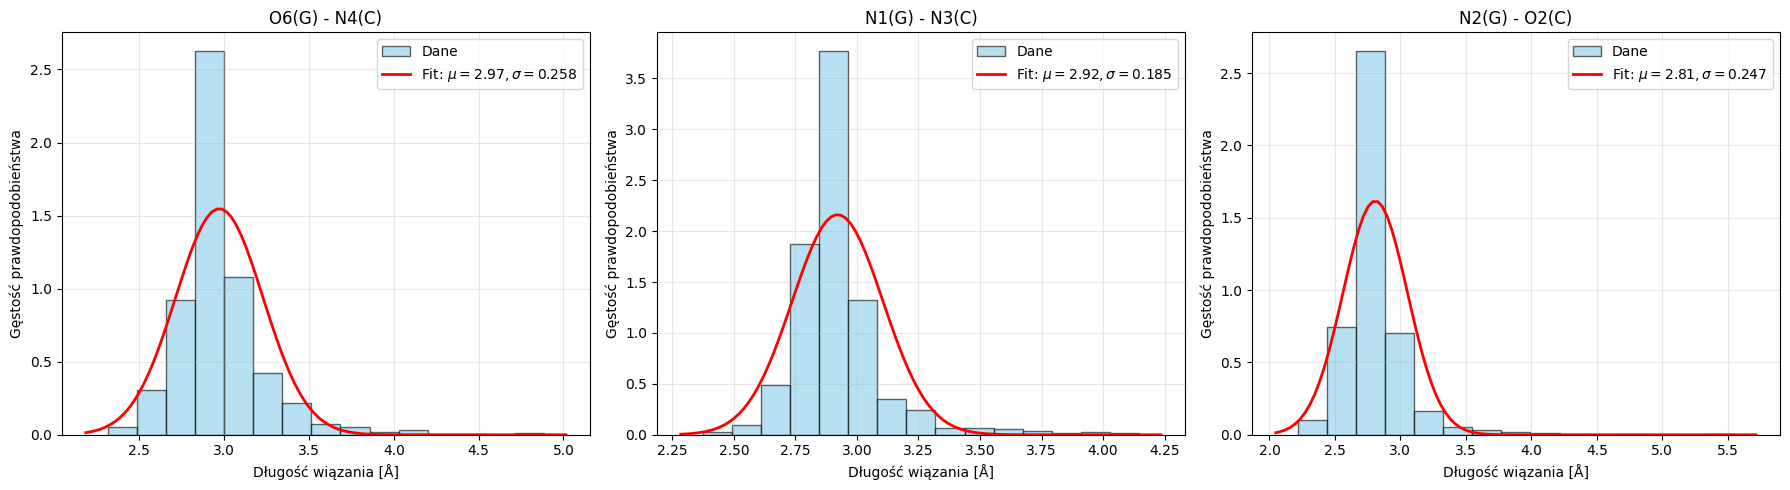

------------------------------------------------------------
WIĄZANIE             | ŚREDNIA (mu)    | ODCHYLENIE (sigma)
------------------------------------------------------------
O6(G) - N4(C)        | 2.9713          | 0.2579         
N1(G) - N3(C)        | 2.9213          | 0.1846         
N2(G) - O2(C)        | 2.8081          | 0.2468         
------------------------------------------------------------
Najmniejsze mu: N2(G) - O2(C) (2.8081 A)
Najmniejsza sigma: N1(G) - N3(C) (sigma=0.1846)


In [58]:
# Ustawienia wykresów
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bond_data = [
    (d_O6_N4, "O6(G) - N4(C)"),
    (d_N1_N3, "N1(G) - N3(C)"),
    (d_N2_O2, "N2(G) - O2(C)")
]

results_stats = []

for i, (data, title) in enumerate(bond_data):
    if not data:
        continue
        
    # 1. Dopasowanie rozkładu normalnego
    mu, std = norm.fit(data)
    results_stats.append((title, mu, std))
    
    # 2. Histogram
    ax = axes[i]
    ax.hist(data, bins=15, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Dane')
    
    # 3. Krzywa Gaussa
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'r', linewidth=2, label=rf'Fit: $\mu={mu:.2f}, \sigma={std:.3f}$')
    
    # Opisy
    ax.set_title(title)
    ax.set_xlabel("Długość wiązania [Å]")
    ax.set_ylabel("Gęstość prawdopodobieństwa")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Wypisanie wniosków tekstowych
print("-" * 60)
print(f"{'WIĄZANIE':<20} | {'ŚREDNIA (mu)':<15} | {'ODCHYLENIE (sigma)':<15}")
print("-" * 60)
for title, mu, std in results_stats:
    print(f"{title:<20} | {mu:<15.4f} | {std:<15.4f}")
print("-" * 60)

best_bond = min(results_stats, key=lambda x: x[1]) # Najkrótsze
most_stable = min(results_stats, key=lambda x: x[2]) # Najmniejsze sigma

print(f"Najmniejsze mu: {best_bond[0]} ({best_bond[1]:.4f} A)")
print(f"Najmniejsza sigma: {most_stable[0]} (sigma={most_stable[2]:.4f})")

## Wnioski:
Najkrótsze wiązanie, czyli mające najsilniejsze przyciąganie to N2(G) - O2(C) (2.8081 A)

Najstabilniejsze wiązanie, czyli mające najmniejsze fluktuacje to N1(G) - N3(C) (sigma=0.1846)

# Ocena 4.5
## Wyznaczanie Potencjału Siły Średniej (PMF)
Wykorzystanie odwróconego rozkładu Boltzmanna do obliczenia profilu energetycznego wiązań wodorowych.

$$U(x) = -k_B T \ln[P(x)]$$

Ponieważ P(x) przybliżamy rozkładem normalnym, energia przyjmuje postać potencjału harmonicznego:
$$U(x) \approx \frac{\kappa}{2}(x - \mu)^2$$

Zdefiniowanie funkcji liczącej energię U(x) = -RT * ln(P(x))
* x: zmierzona długość wiązania
* mu, sigma: parametry rozkładu normalnego dla tego typu wiązania
* RT: energia termiczna

In [ ]:
# Funkcja obliczająca energię PMF dla pojedynczego wiązania
def calculate_bond_energy(x, mu, sigma, RT):
    # Gęstość prawdopodobieństwa
    prob = norm.pdf(x, mu, sigma)
    
    # Zabezpieczenie przed logarytmem z zera (epsilon maszynowy)
    epsilon = np.nextafter(0, 1)
    safe_prob = max(prob, epsilon)
    
    # Obliczenie energii
    u_x = -RT * np.log(safe_prob)
    return u_x

# Pobranie parametrów mu i sigma z poprzedniego zadania (z listy results_stats)
# Kolejność w results_stats była: 0: O6-N4, 1: N1-N3, 2: N2-O2
p_O6_N4 = results_stats[0] # (tytuł, mu, sigma)
p_N1_N3 = results_stats[1]
p_N2_O2 = results_stats[2]

print("Użyte parametry rozkładów:")
print(f"1. {p_O6_N4[0]}: mu={p_O6_N4[1]:.4f}, sigma={p_O6_N4[2]:.4f}")
print(f"2. {p_N1_N3[0]}: mu={p_N1_N3[1]:.4f}, sigma={p_N1_N3[2]:.4f}")
print(f"3. {p_N2_O2[0]}: mu={p_N2_O2[1]:.4f}, sigma={p_N2_O2[2]:.4f}")

Użyte parametry rozkładów:
1. O6(G) - N4(C): mu=2.9713, sigma=0.2579
2. N1(G) - N3(C): mu=2.9213, sigma=0.1846
3. N2(G) - O2(C): mu=2.8081, sigma=0.2468


## Główna pętla obliczeniowa
W tej komórce ponownie przetwarzne są pliki PDB, mierzone są konkretne długości w każdym pliku i sumowana jest energia.

In [ ]:
import statistics

# Lista do przechowywania wyników PMF: (ścieżka, energia_całkowita)
pmf_results = []

for filepath in gc_files:
    try:
        structure = parser.get_structure('PMF_calc', filepath)
        
        g_res = None
        c_res = None
        
        # Znajdowanie rezyduów
        for model in structure:
            for chain in model:
                for residue in chain:
                    res_name = residue.get_resname().strip().upper()
                    if res_name in ['G', 'DG', 'GUA', '5GP']:
                        g_res = residue
                    elif res_name in ['C', 'DC', 'CYT', '5CM']:
                        c_res = residue
        
        if g_res and c_res:
            try:
                # 1. Pobranie długości wiązań
                r1 = g_res['O6'] - c_res['N4']
                r2 = g_res['N1'] - c_res['N3']
                r3 = g_res['N2'] - c_res['O2']
                
                # 2. Obliczenie energii cząstkowych (korzystamy z funkcji zdefiniowanej wyżej)
                # Używamy globalnego RT zdefiniowanego w zadaniu 3.5 (ok. 0.596 kcal/mol)
                u1 = calculate_bond_energy(r1, p_O6_N4[1], p_O6_N4[2], RT)
                u2 = calculate_bond_energy(r2, p_N1_N3[1], p_N1_N3[2], RT)
                u3 = calculate_bond_energy(r3, p_N2_O2[1], p_N2_O2[2], RT)
                
                # 3. Suma energii
                u_total = u1 + u2 + u3
                
                pmf_results.append((filepath, u_total))
                
            except KeyError:
                continue # Pomijamy uszkodzone struktury
                
    except Exception as e:
        print(f"Błąd pliku {os.path.basename(filepath)}: {e}")

# Sortowanie wyników wg energii (od najniższej/najbardziej zrelaksowanej)
pmf_results.sort(key=lambda x: x[1])

print(f"Przeliczono energie dla {len(pmf_results)} struktur.")


Obliczanie energii PMF dla 1000 struktur...
Przeliczono energie dla 1000 struktur.


## Statystyka i Wyświetlanie
Obliczenie mediany, prawdopodobieństw względnych i wyświetlenie listy.

In [72]:
# 1. Wyznaczenie mediany energii całkowitej
energies_pmf = [res[1] for res in pmf_results]
median_pmf = statistics.median(energies_pmf)

print(f"Mediana energii wiązań (PMF): {median_pmf:.4f} kcal/mol\n")

# 2. Obliczenie prawdopodobieństwa względnego i wyświetlenie
print("-" * 75)
print(f"{'PLIK':<25} | {'U_total (kcal/mol)':>20} | {'P(x)/P(mediana)':>25}")
print("-" * 75)

for filepath, u_tot in pmf_results:
    # Wzór Boltzmanna względem mediany
    delta_u = u_tot - median_pmf
    try:
        prob_ratio = np.exp(-delta_u / RT)
    except OverflowError:
        prob_ratio = 0.0
    
    filename = os.path.basename(filepath)
    
    # Wyświetlanie
    print(f"{filename:<25} | {u_tot:20.4f} | {prob_ratio:25.4e}")

print("-" * 75)

# Podsumowanie skrajnych przypadków
best_struct = pmf_results[0]
worst_struct = pmf_results[-1]

print("\nPODSUMOWANIE:")
print(f"Struktura o najniższej energii (najbardziej prawdopodobna): {os.path.basename(best_struct[0])}")
print(f" -> Energia: {best_struct[1]:.4f} kcal/mol")
print(f"Struktura o najwyższej energii (najmniej prawdopodobna):   {os.path.basename(worst_struct[0])}")
print(f" -> Energia: {worst_struct[1]:.4f} kcal/mol")

Mediana energii wiązań (PMF): -0.7906 kcal/mol

---------------------------------------------------------------------------
PLIK                      |   U_total (kcal/mol) |           P(x)/P(mediana)
---------------------------------------------------------------------------
213.pdb                   |              -1.0050 |                1.4330e+00
316.pdb                   |              -1.0045 |                1.4317e+00
86.pdb                    |              -1.0043 |                1.4312e+00
580.pdb                   |              -1.0033 |                1.4287e+00
529.pdb                   |              -1.0020 |                1.4258e+00
536.pdb                   |              -1.0017 |                1.4251e+00
57.pdb                    |              -1.0010 |                1.4232e+00
656.pdb                   |              -1.0009 |                1.4231e+00
751.pdb                   |              -0.9994 |                1.4194e+00
843.pdb                   |   

**Wnioski**

Struktura najbardzie zrelaksowana to 213.pdb,

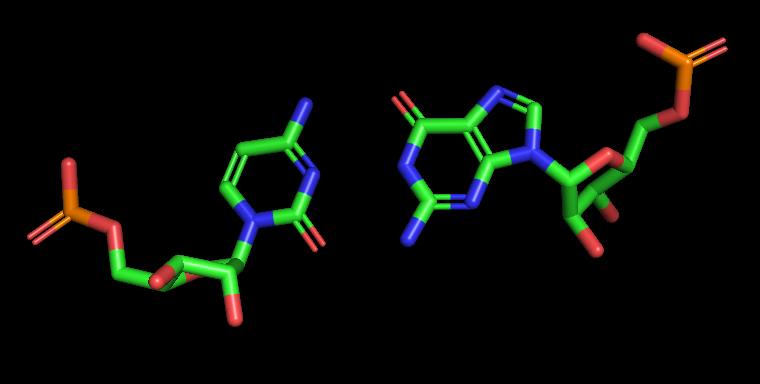


a najmniej to 671.pdb.

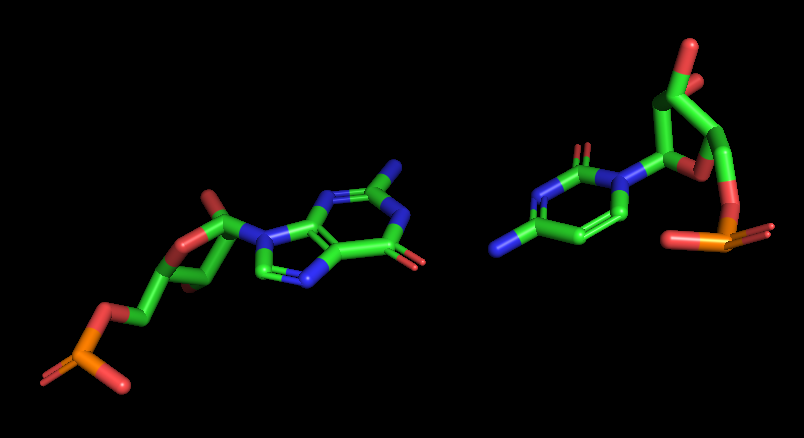

# Ocena 5.0
## Optymalizacja geometrii metodą Monte Carlo

Celem tego etapu jest znalezienie najniższej energetycznie konfiguracji przestrzennej pary Guanina-Cytozyna. Algorytm startuje z zaburzonej struktury i próbuje dopasować Cytozynę do nieruchomej Guaniny.

**Funkcja Energii:**
Całkowita energia układu jest sumą potencjałów harmonicznych (PMF - wiązania wodorowe) oraz oddziaływań Lennarda-Jonesa (LJ - odpychanie atomów węgla):

$$U_{total}(X) = U_{PMF}(r_{HB}) + U_{LJ}(r_{CC})$$

### Import niezbędnych bibliotek
Importujemy `numpy` do szybkich obliczeń macierzowych, `copy` do kopiowania obiektów oraz `PDBIO` do zapisu wynikowego pliku.

In [62]:
import numpy as np
import copy
from Bio.PDB import PDBIO

### Definicje macierzy rotacji
Poniższe funkcje definiują macierze obrotu punktu w przestrzeni 3D wokół poszczególnych osi kartezjańskich (X, Y, Z) o zadany kąt $\theta$.

In [63]:
def rotation_matrix_x(theta):
    return np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)]
    ])

def rotation_matrix_y(theta):
    return np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

def rotation_matrix_z(theta):
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

### Funkcja składająca rotacje
Ta funkcja tworzy jedną macierz rotacji $M$, która jest złożeniem obrotów wokół wszystkich trzech osi: $M = M_z \cdot M_y \cdot M_x$.

In [64]:
def get_rotation_matrix(tx, ty, tz):
    Mx = rotation_matrix_x(tx)
    My = rotation_matrix_y(ty)
    Mz = rotation_matrix_z(tz)
    # Kolejność mnożenia ma znaczenie (najpierw X, potem Y, potem Z)
    return Mz @ My @ Mx

### Wczytanie struktury początkowej
Wczytujemy plik `simulate.pdb` (lub plik zastępczy, jeśli `simulate.pdb` nie istnieje) i identyfikujemy obiekty `Residue` odpowiadające Guaninie i Cytozynie.

In [65]:
# Używamy pliku simulate.pdb jeśli istnieje, w przeciwnym razie bierzemy pierwszy z listy wyników jako fallback
sim_file = "simulate.pdb" if os.path.exists("simulate.pdb") else results[0][0]
print(f"Rozpoczynam symulację na strukturze: {sim_file}")

structure = parser.get_structure('Simulation', sim_file)

g_res = None
c_res = None

for model in structure:
    for chain in model:
        for residue in chain:
            res_name = residue.get_resname().strip().upper()
            if res_name in ['G', 'DG', 'GUA', '5GP'] and g_res is None:
                g_res = residue
            elif res_name in ['C', 'DC', 'CYT', '5CM'] and c_res is None:
                c_res = residue

if not g_res or not c_res:
    raise ValueError("Nie znaleziono pary G-C w pliku wejściowym.")

Rozpoczynam symulację na strukturze: GC\lj\GC_33.pdb


### Przygotowanie danych statycznych (Guanina)
Guanina pozostaje nieruchoma podczas symulacji. Pobieramy współrzędne atomów biorących udział w wiązaniach wodorowych (O6, N1, N2) oraz wszystkich atomów węgla (do obliczeń LJ) i zapisujemy je w macierzach NumPy.

In [66]:
# Atomy referencyjne w Guaninie (cele wiązań wodorowych)
G_O6 = np.array(g_res['O6'].get_coord())
G_N1 = np.array(g_res['N1'].get_coord())
G_N2 = np.array(g_res['N2'].get_coord())

# Atomy węgla w Guaninie (do potencjału Lennarda-Jonesa)
G_carbons = np.array([atom.get_coord() for atom in g_res if atom.get_name().startswith('C')])

print(f"Liczba atomów węgla w Guaninie: {len(G_carbons)}")

Liczba atomów węgla w Guaninie: 10


### Przygotowanie danych dynamicznych (Cytozyna)
Pobieramy wszystkie atomy Cytozyny do jednej macierzy, aby móc obracać całą cząsteczkę jako sztywne ciało. Zapamiętujemy również indeksy (pozycje w tablicy) dla kluczowych atomów (N4, N3, O2 oraz węgli), aby szybko odwoływać się do nich podczas obliczania energii.

In [67]:
# Pobieramy wszystkie atomy jako listę
c_atom_list = list(c_res.get_atoms())

# Macierz współrzędnych startowych (N_atomów x 3)
c_coords_start = np.array([atom.get_coord() for atom in c_atom_list])

# Mapowanie indeksów ważnych atomów w tablicy c_coords_start
# Dzięki temu wiemy, który wiersz macierzy odpowiada któremu atomowi
idx_N4 = next(i for i, a in enumerate(c_atom_list) if a.get_name() == 'N4')
idx_N3 = next(i for i, a in enumerate(c_atom_list) if a.get_name() == 'N3')
idx_O2 = next(i for i, a in enumerate(c_atom_list) if a.get_name() == 'O2')

# Indeksy wszystkich atomów węgla w Cytozynie
c_carbon_indices = [i for i, a in enumerate(c_atom_list) if a.get_name().startswith('C')]

print(f"Liczba atomów węgla w Cytozynie: {len(c_carbon_indices)}")

Liczba atomów węgla w Cytozynie: 9


### Funkcja Energii Całkowitej
Funkcja ta przyjmuje aktualne współrzędne wszystkich atomów Cytozyny i zwraca całkowitą energię układu.
Składa się ona z:
1. **Energii PMF** dla trzech wiązań wodorowych (używając parametrów $\mu$ i $\sigma$ wyliczonych w zadaniu 4.5).
2. **Energii Lennarda-Jonesa** sumowanej dla wszystkich par atomów węgla między Guaniną a Cytozyną.

In [68]:
def calculate_total_energy(current_c_coords):
    """
    current_c_coords: macierz numpy (Nx3) z położeniem atomów Cytozyny
    """
    energy_pmf = 0.0
    energy_lj = 0.0
    
    # 1. Energia Wiązań Wodorowych (PMF)
    # Korzystamy ze zmiennych p_O6_N4, p_N1_N3, p_N2_O2 z poprzednich zadań
    
    # Wiązanie 1: O6(G) - N4(C)
    dist_1 = np.linalg.norm(G_O6 - current_c_coords[idx_N4])
    energy_pmf += calculate_bond_energy(dist_1, p_O6_N4[1], p_O6_N4[2], RT)
    
    # Wiązanie 2: N1(G) - N3(C)
    dist_2 = np.linalg.norm(G_N1 - current_c_coords[idx_N3])
    energy_pmf += calculate_bond_energy(dist_2, p_N1_N3[1], p_N1_N3[2], RT)
    
    # Wiązanie 3: N2(G) - O2(C)
    dist_3 = np.linalg.norm(G_N2 - current_c_coords[idx_O2])
    energy_pmf += calculate_bond_energy(dist_3, p_N2_O2[1], p_N2_O2[2], RT)
    
    # 2. Energia Lennarda-Jonesa (Odpychanie węgli)
    # Pobieramy współrzędne tylko węgli z Cytozyny
    C_carbons_coords = current_c_coords[c_carbon_indices]
    
    # Obliczamy macierz odległości między wszystkimi węglami G i wszystkimi węglami C
    # Wykorzystujemy broadcasting NumPy: (M, 1, 3) - (1, K, 3) -> (M, K, 3)
    diff = G_carbons[:, np.newaxis, :] - C_carbons_coords[np.newaxis, :, : ]
    dists = np.sqrt(np.sum(diff**2, axis=2))
    
    # Sumujemy potencjał LJ dla wszystkich par (iterujemy po spłaszczonej tablicy odległości)
    for r in dists.flat:
        energy_lj += lennard_jones_potential(r, EPSILON, SIGMA)
        
    return energy_pmf + energy_lj

### Inicjalizacja Symulacji
Ustawiamy parametry symulacji (liczba kroków, maksymalny kąt obrotu, maksymalne przesunięcie) oraz obliczamy energię dla struktury startowej.

In [69]:
# Parametry Monte Carlo
STEPS = 10000
MAX_ROT = np.pi / 12  # ok. 15 stopni
MAX_TRANS = 1.0       # 1 Angstrom

# Stan początkowy
best_c_coords = np.copy(c_coords_start)
best_energy = calculate_total_energy(best_c_coords)

print(f"Energia początkowa: {best_energy:.4f} kcal/mol")

Energia początkowa: 363.4995 kcal/mol


### Pętla Symulacyjna (Monte Carlo)
W każdej iteracji:
1. Losujemy kąty obrotu i wektor przesunięcia.
2. Generujemy nową, próbną geometrię Cytozyny.
3. Liczymy energię.
4. Jeśli energia spadła, akceptujemy ruch i aktualizujemy `best_coords`.

In [70]:
accepted_steps = 0

for k in range(STEPS):
    # 1. Losowanie parametrów ruchu
    theta = np.random.uniform(-MAX_ROT, MAX_ROT, 3) # 3 losowe kąty
    v = np.random.uniform(-MAX_TRANS, MAX_TRANS, 3) # wektor przesunięcia
    
    # 2. Konstrukcja macierzy rotacji
    M = get_rotation_matrix(theta[0], theta[1], theta[2])
    
    # 3. Obliczenie próbnych współrzędnych
    # Wzór: X_trial = X_best * M^T + v
    trial_c_coords = best_c_coords @ M.T + v
    
    # 4. Obliczenie energii
    trial_energy = calculate_total_energy(trial_c_coords)
    
    # 5. Decyzja (Algorytm zachłanny - akceptujemy tylko lepsze)
    if trial_energy < best_energy:
        best_energy = trial_energy
        best_c_coords = trial_c_coords
        accepted_steps += 1
        
        # Logowanie postępu co 1000 kroków
        if k % 1000 == 0:
            print(f"Iteracja {k}: Znaleziono niższą energię = {best_energy:.4f} kcal/mol")

print(f"\nSymulacja zakończona.")
print(f"Zaakceptowano zmian: {accepted_steps}")
print(f"Najniższa osiągnięta energia: {best_energy:.4f} kcal/mol")


Symulacja zakończona.
Zaakceptowano zmian: 8
Najniższa osiągnięta energia: -1.5735 kcal/mol


### Zapis wyników
Aktualizujemy obiekt Biopython nowymi współrzędnymi atomów Cytozyny i zapisujemy zoptymalizowaną strukturę do pliku `optimized_GC.pdb`.

In [71]:
# Aktualizacja współrzędnych w obiekcie struktury
# (best_c_coords to macierz, musimy wpisać wartości z powrotem do obiektów Atom)
for i, atom in enumerate(c_atom_list):
    atom.set_coord(best_c_coords[i])

# Zapis do pliku PDB
io = PDBIO()
io.set_structure(structure)
output_filename = "optimized_GC.pdb"
io.save(output_filename)

print(f"Zoptymalizowaną strukturę zapisano do pliku: {output_filename}")

Zoptymalizowaną strukturę zapisano do pliku: optimized_GC.pdb


## Analiza i Wnioski
Analizując wizualizację w pyMOL można zaobserwować
* Para DNA jest ułożona niemal, że w jednej płaszczyźnie, jest to kluczone dla układanie się piętrowo nici DNA.
* Trzy wiązania wodorowe (O6-N4, N1-N3, N2-O2) mają długości zbliżone do wartości idealnych wyznaczonych w zadaniu 4.0 (ok. 2.9 Å). Wynoszą one: 
    * O6-N4 = 3.0
    * N1-N3 = 2.9
    * N2-O2 = 2.8

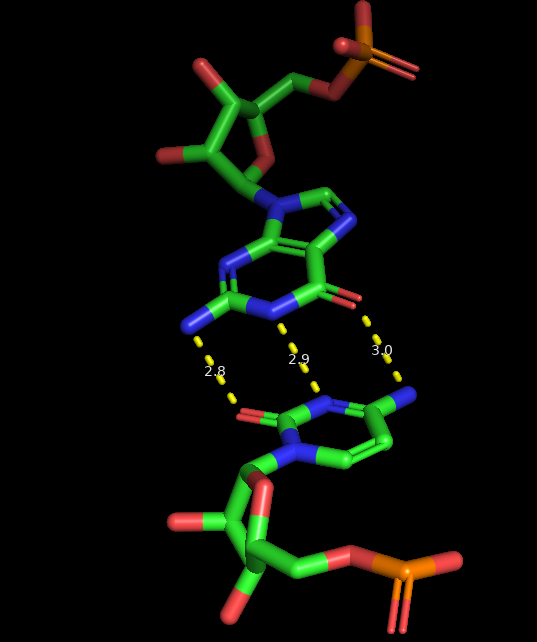


* Dzięki potencjałowi Lennarda-Jonesa, atomy węgla nie nachodzą na siebie.

Algorytm Monte Carlo skutecznie zminimalizował energię układu, doprowadzając do powstania stabilnej pary Watsona-Cricka.